In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import pickle
import os

df = pd.read_csv("../data/raw/breast_cancer.csv")

X = df.drop('target', axis=1)
y = df['target']

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"\nDistribución de clases:\n{y.value_counts()}")

Features: (569, 30)
Target: (569,)

Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Clases: {y_train.value_counts().to_dict()}")
print(f"Test:  {X_test.shape} | Clases: {y_test.value_counts().to_dict()}")

Train: (455, 30) | Clases: {1: 285, 0: 170}
Test:  (114, 30) | Clases: {1: 72, 0: 42}


In [3]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # solo transform, nunca fit en test

print("Escalado aplicado correctamente")
print(f"Train escalado: {X_train_scaled.shape}")
print(f"Test escalado:  {X_test_scaled.shape}")

Escalado aplicado correctamente
Train escalado: (455, 30)
Test escalado:  (114, 30)


Varianza explicada por componente: [0.44190102 0.19969806]
Varianza total explicada: 64.16%


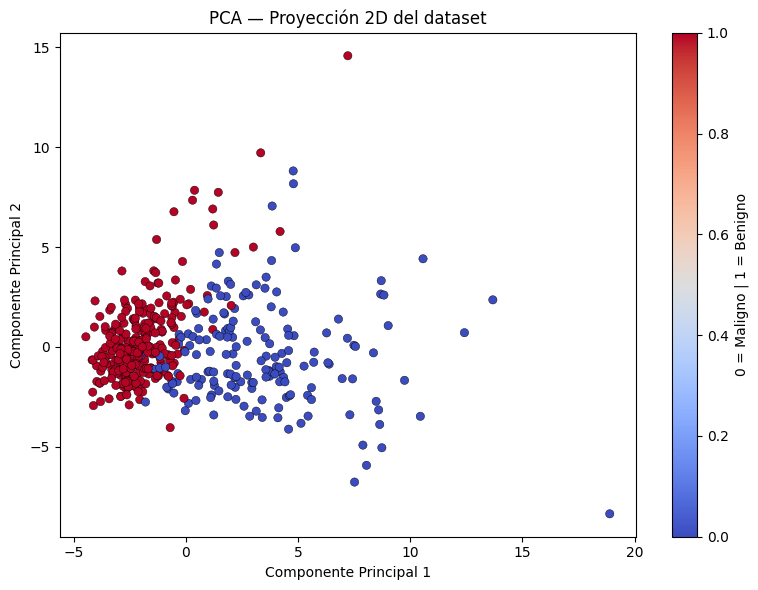

In [7]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Varianza explicada
print(f"Varianza explicada por componente: {pca.explained_variance_ratio_}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.2%}")

# Visualización
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap='coolwarm',
    alpha=1,
    edgecolors='k',
    linewidths=0.3
)

plt.colorbar(scatter, label='0 = Maligno | 1 = Benigno')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA — Proyección 2D del dataset')
plt.tight_layout()
plt.show()

## PCA — Reducción de Dimensionalidad

Con 2 componentes principales se captura el 64.16% de la varianza total del dataset 
(44.19% + 19.97%), lo que confirma la alta redundancia entre las 30 features 
originales detectada en el análisis de correlación.

La proyección 2D muestra separación visible entre clases, con los tumores malignos 
concentrados en valores negativos del Componente 1 y los benignos extendiéndose 
hacia valores positivos. El traslape en la zona central es esperado al reducir 
30 dimensiones a solo 2.

Los outliers detectados en el análisis de boxplots son visibles como puntos aislados 
en los extremos de la proyección.

In [9]:
os.makedirs("models", exist_ok=True)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("models/pca.pkl", "wb") as f:
    pickle.dump(pca, f)

print("Scaler y PCA guardados en models/")

Scaler y PCA guardados en models/
